# Build full-range spectra from Aurora climate caches

## Goal

Turn selected converged `NPZ` + `PKL` climate-cache pairs into validated NetCDF spectra and a meeting-ready comparison figure. This notebook uses the full configured **0.30–15 µm** wavelength range at **R = 1500** and computes both reflected light and thermal emission.

## Setup

The notebook imports the adjacent tested builder module. That module handles PICASO reference-data paths, cache loading, row reconstruction, spectral calculations, NetCDF schema construction, and plotting.

**Key assumptions**

- Each selected NPZ has its matching PICASO case PKL.
- `climate_converged = 1` is required before spectrum generation.

In [1]:
from pathlib import Path
import importlib.util
import json

import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import Image, display

NOTEBOOK_DIR = Path.cwd()
MODULE_PATH = NOTEBOOK_DIR / "build_representative_spectra.py"
spec = importlib.util.spec_from_file_location("representative_spectra_builder", MODULE_PATH)
builder = importlib.util.module_from_spec(spec)
spec.loader.exec_module(builder)

print(f"Builder: {MODULE_PATH}")
print(f"Climate cache: {builder.CACHE_DIR}")
print("Output wavelength range: 0.30–15 µm at R = 1500")

Builder: /Users/dhuang/Documents/daniel/research/aurora/reports/representative_spectra_2026-07-16/build_representative_spectra.py
Climate cache: /Users/dhuang/Documents/daniel/research/aurora/roadrunner_egp/aurora_subneptune_grid/outputs/aurora_subneptune_v1_dhuang/climate_cache
Output wavelength range: 0.30–15 µm at R = 1500


## Steps

### 1. Review the selected cases

Edit `SELECTED_CASES` to change the comparison. Climate-group indices must refer to existing converged cache pairs.

In [2]:
SELECTED_CASES = [dict(case) for case in builder.CASES]
case_table = pd.DataFrame(SELECTED_CASES)[
    ["case_id", "label", "climate_group_index", "metallicity_xsolar", "cloud_fraction", "rationale"]
]
display(case_table)

,case_id,label,climate_group_index,metallicity_xsolar,cloud_fraction,rationale
0,case01_clear_solar,"Clear, 1× solar metallicity",23611,1.0,0.0,Reference atmosphere; isolates the baseline mo...
1,case02_cloudy_solar,"Fully cloudy, 1× solar metallicity",23691,1.0,1.0,Cloud comparison at fixed composition; shows c...
2,case03_clear_100x_solar,"Clear, 100× solar metallicity",24811,100.0,0.0,Composition comparison without clouds; shows t...


### 2. Validate the input NPZ/PKL pairs

In [3]:
input_checks = []
for case in SELECTED_CASES:
    npz_path = builder.cache_path(case["climate_group_index"])
    pkl_path = npz_path.with_name(f"{npz_path.stem}_case.pkl")
    with np.load(npz_path, allow_pickle=False) as archive:
        metadata = json.loads(str(archive["metadata_json"]))
    input_checks.append({
        "case_id": case["case_id"],
        "climate_group_index": case["climate_group_index"],
        "npz_exists": npz_path.is_file(),
        "pkl_exists": pkl_path.is_file(),
        "climate_converged": int(metadata.get("diagnostics", {}).get("climate_converged", 0)),
        "opacity_file": Path(metadata["selected_ck_file"]).name,
    })

input_check_table = pd.DataFrame(input_checks)
display(input_check_table)
assert input_check_table[["npz_exists", "pkl_exists"]].all().all()
assert input_check_table["climate_converged"].eq(1).all()

,case_id,climate_group_index,npz_exists,pkl_exists,climate_converged,opacity_file
0,case01_clear_solar,23611,True,True,1,sonora_2121grid_feh0.0_co0.55.hdf5
1,case02_cloudy_solar,23691,True,True,1,sonora_2121grid_feh0.0_co0.55.hdf5
2,case03_clear_100x_solar,24811,True,True,1,sonora_2121grid_feh2.0_co0.55.hdf5


### 3. Generate the spectra and NetCDF files

For each case, the builder loads the climate pair, computes reflected and thermal spectra, constructs the Aurora schema, runs QC, and writes the `.nc` file.

In [4]:
config = builder.load_config()
results = []
for case in SELECTED_CASES:
    print(f"Building {case['case_id']} from climate group {case['climate_group_index']}...")
    results.append(builder.build_case(config, case))

result_table = pd.DataFrame(results)
display(result_table[[
    "case_id", "output_nc", "wavelength_points", "runtime_seconds", "schema_warnings", "science_flags"
]])

Building case01_clear_solar from climate group 23611...


Building case02_cloudy_solar from climate group 23691...


Building case03_clear_100x_solar from climate group 24811...


,case_id,output_nc,wavelength_points,runtime_seconds,schema_warnings,science_flags
0,case01_clear_solar,/Users/dhuang/Documents/daniel/research/aurora...,5870,0.683,,
1,case02_cloudy_solar,/Users/dhuang/Documents/daniel/research/aurora...,5870,0.439,,
2,case03_clear_100x_solar,/Users/dhuang/Documents/daniel/research/aurora...,5870,0.425,,


## Checks

### 4. Reopen and validate the written NetCDF files

In [5]:
qa_rows = []
for result in results:
    with xr.open_dataset(result["output_nc"]) as dataset:
        schema_issues = builder.validate_aurora_netcdf_schema(dataset)
        science_flags = builder.validate_science(dataset)
        wavelength = np.asarray(dataset["wavelength_um"].values, dtype=float)
        total_ppm = 1e6 * np.asarray(dataset["total_planet_star_flux_ratio"].values, dtype=float)
        qa_rows.append({
            "case_id": result["case_id"],
            "wavelength_points": dataset.sizes["wavelength"],
            "wavelength_min_um": wavelength.min(),
            "wavelength_max_um": wavelength.max(),
            "total_contrast_min_ppm": total_ppm.min(),
            "total_contrast_max_ppm": total_ppm.max(),
            "schema_errors": sum(issue.startswith("ERROR:") for issue in schema_issues),
            "science_failures": sum(flag.severity == "fail" for flag in science_flags),
        })

qa_table = pd.DataFrame(qa_rows)
display(qa_table)
assert qa_table["wavelength_min_um"].between(0.299, 0.301).all()
assert qa_table["wavelength_max_um"].between(14.99, 15.01).all()
assert qa_table[["schema_errors", "science_failures"]].eq(0).all().all()

,case_id,wavelength_points,wavelength_min_um,wavelength_max_um,total_contrast_min_ppm,total_contrast_max_ppm,schema_errors,science_failures
0,case01_clear_solar,5870,0.3,15.0,0.000021,49.582730,0,0
1,case02_cloudy_solar,5870,0.3,15.0,0.000022,50.304518,0,0
2,case03_clear_100x_solar,5870,0.3,15.0,0.000002,56.488466,0,0


### 5. Render the comparison spectra

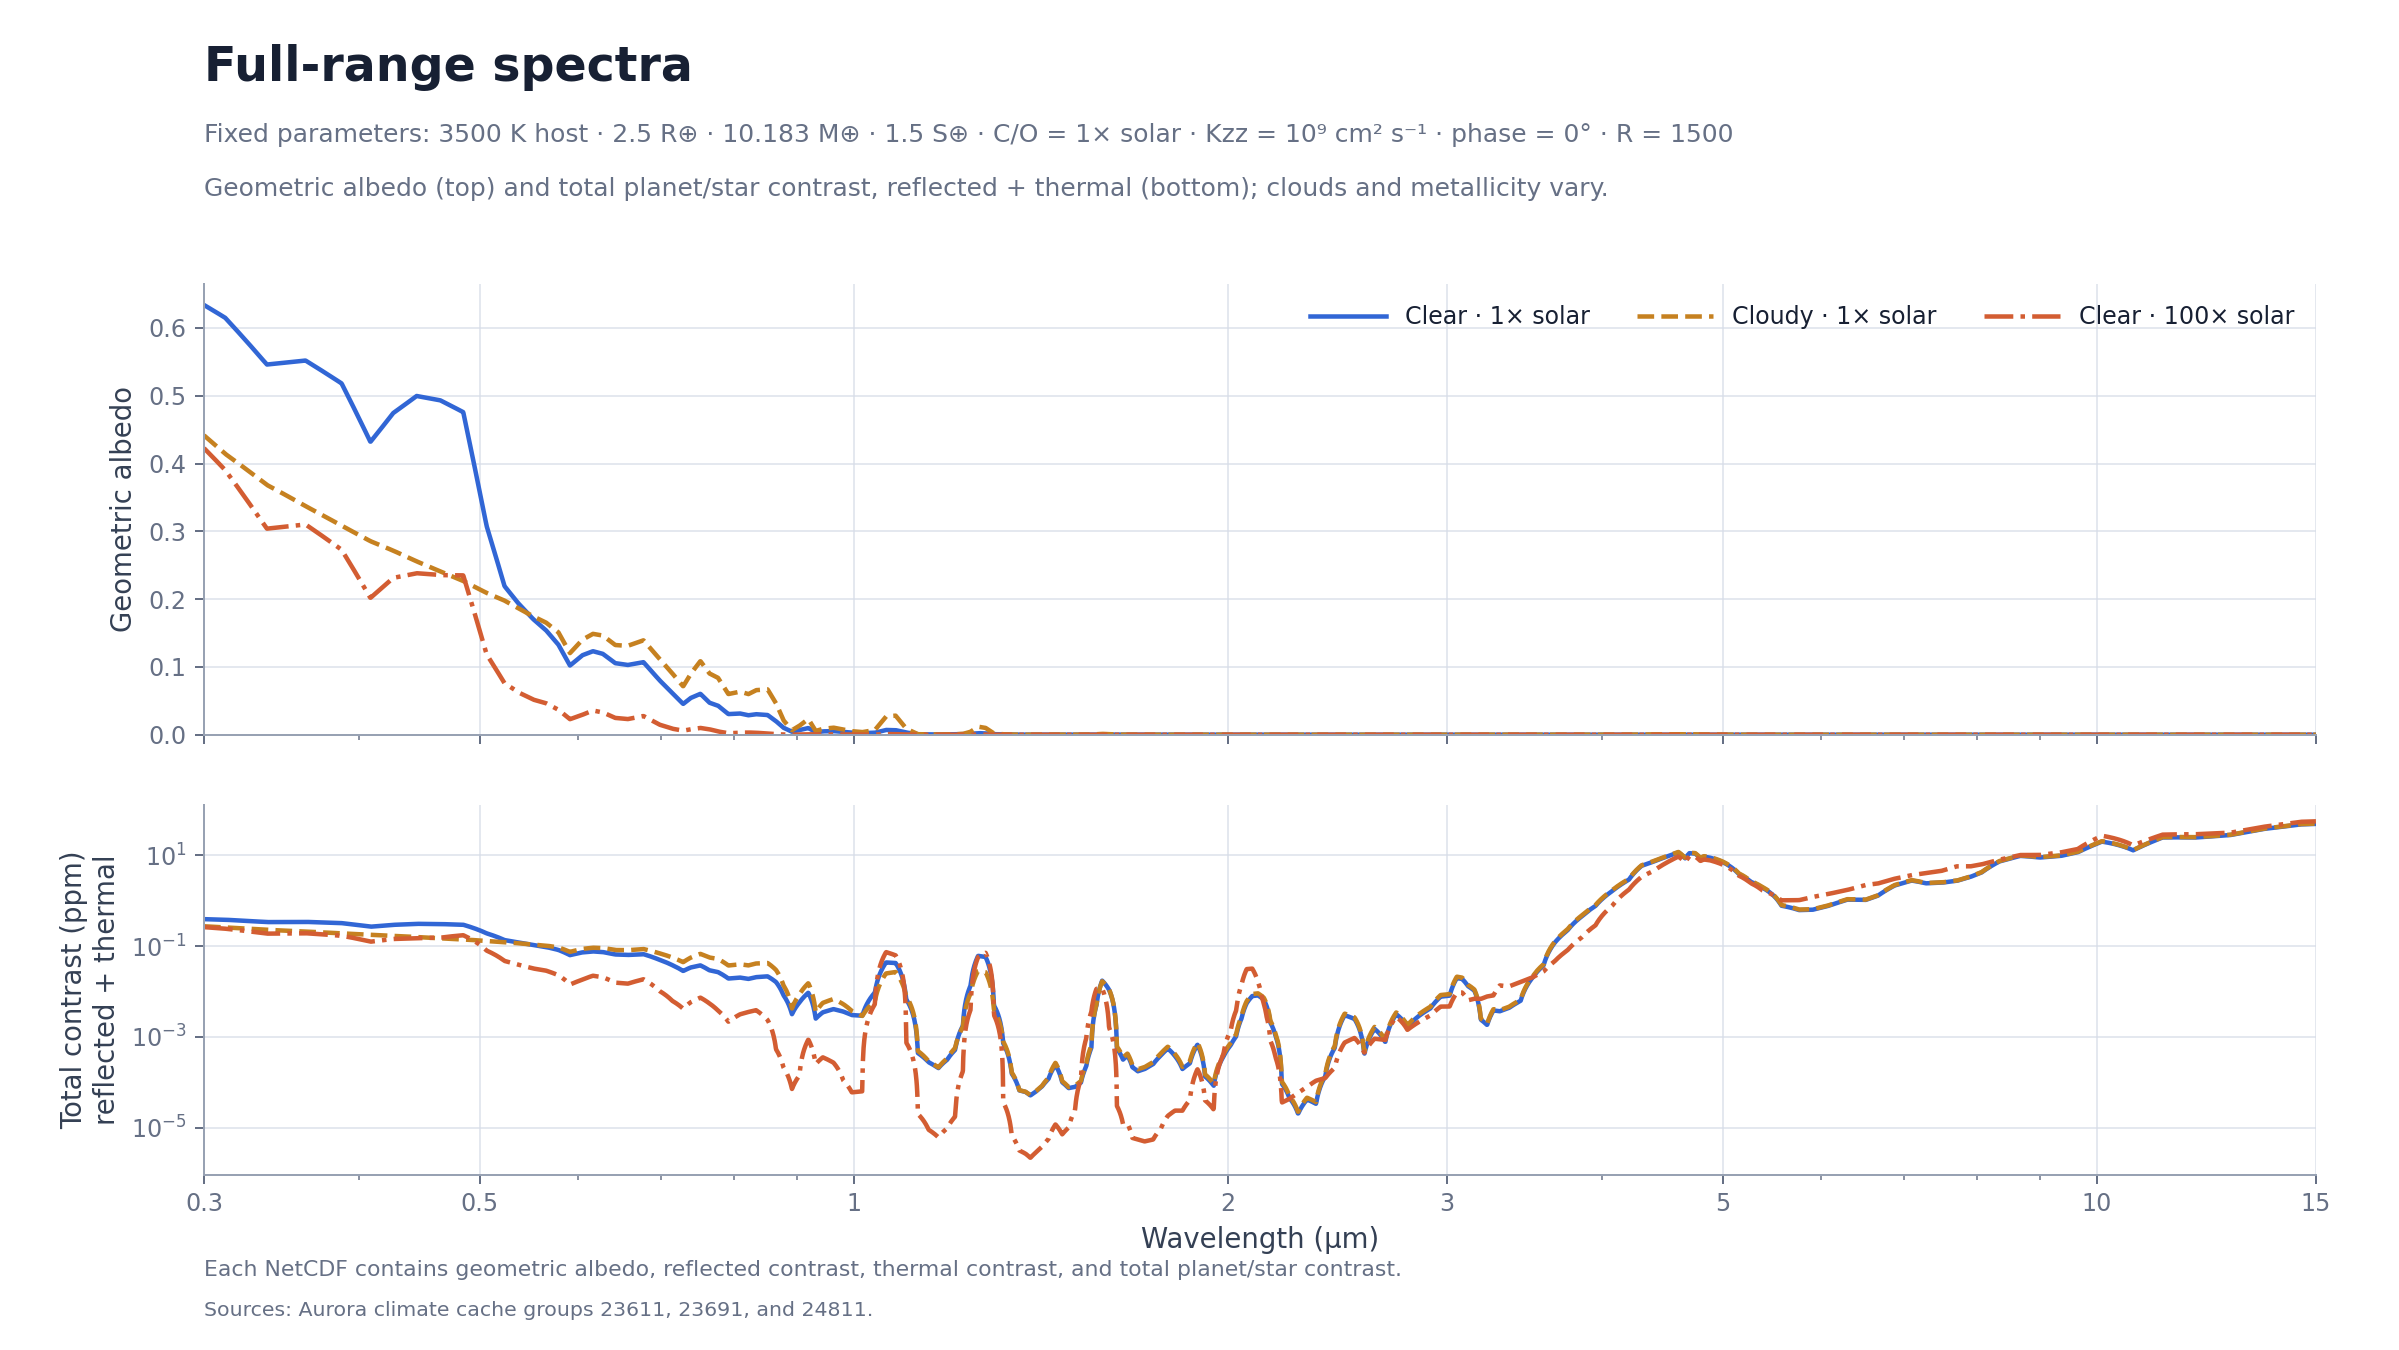

In [6]:
builder.write_manifest(results)
builder.write_summary(results)
builder.render_plot(results)
display(Image(filename=str(builder.OUT_DIR / "representative_spectra.png")))

## Next Steps

- Use the generated PNG/SVG as the spectrum panel in the meeting slide.
- Share the three NetCDF files when collaborators need the underlying wavelength-resolved data.
- To explore another physical effect, change one parameter at a time and select matching converged climate-group indices.

The executed checks above require 0.30–15 µm coverage, zero schema errors, and zero science failures for every generated file.

In [7]:
print("Generated NetCDF files:")
for result in results:
    print(f"- {result['output_nc']}")
print(f"Figure: {builder.OUT_DIR / 'representative_spectra.png'}")

Generated NetCDF files:
- /Users/dhuang/Documents/daniel/research/aurora/reports/representative_spectra_2026-07-16/netcdf/case01_clear_solar.nc
- /Users/dhuang/Documents/daniel/research/aurora/reports/representative_spectra_2026-07-16/netcdf/case02_cloudy_solar.nc
- /Users/dhuang/Documents/daniel/research/aurora/reports/representative_spectra_2026-07-16/netcdf/case03_clear_100x_solar.nc
Figure: /Users/dhuang/Documents/daniel/research/aurora/reports/representative_spectra_2026-07-16/representative_spectra.png
